---
### Cactus Aerial Photos
- https://www.kaggle.com/datasets/irvingvasquez/cactus-aerial-photos
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/deeplearning_study')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
tf.config.list_physical_devices('GPU')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
# kagglehub
#!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("irvingvasquez/cactus-aerial-photos")
print('path:', path)
print('folder:', os.listdir(path))

100%|██████████| 126M/126M [00:00<00:00, 150MB/s]

Extracting files...


path: /root/.cache/kagglehub/datasets/irvingvasquez/cactus-aerial-photos/versions/4
folder: ['training_set', 'test_set']


In [3]:
# train/test folder
train_dir = os.path.join(path, "training_set")
test_dir = os.path.join(path, "test_set")

In [4]:
####################################################################################
# 데이터 증강 & 정규화
####################################################################################

datagen_train = ImageDataGenerator(
    rescale=1/255,           # 픽셀값 정규화 (0~255 → 0~1)
    rotation_range=15,       # 이미지 회전
    width_shift_range=0.1,   # 좌우 이동
    height_shift_range=0.1,  # 상하 이동
    horizontal_flip=True     # 좌우 반전
)

# 테스트 데이터는 증강 없이 정규화만 수행
datagen_test = ImageDataGenerator(
    rescale=1/255
)

In [5]:
####################################################################################
# 이미지 데이터 로딩
# flow_from_directory : 폴더 이름을 자동으로 라벨로 인식
####################################################################################

train_generator = datagen_train.flow_from_directory(
    train_dir,              # 훈련 데이터 폴더
    target_size=(32,32),    # CNN 입력 크기
    batch_size=64,          # 한번에 모델에 들어갈 데이터 개수
    class_mode='binary'     # 이진 분류 (cactus / not_cactus)
)

test_generator = datagen_test.flow_from_directory(
    test_dir,
    target_size=(32,32),
    batch_size=64,
    class_mode='binary'
)

Found 47095 images belonging to 2 classes.
Found 6000 images belonging to 1 classes.


In [6]:
# 클래스 이름과 숫자 매핑 확인
print(train_generator.class_indices)

{'cactus': 0, 'no_cactus': 1}


In [7]:
####################################################################################
# CNN model
####################################################################################

model = keras.Sequential([

    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [8]:
####################################################################################
# compile
####################################################################################

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',    # 이진 분류
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cactus_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [9]:
# training
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.9291 - loss: 0.1734 - val_accuracy: 0.8777 - val_loss: 0.2724
Epoch 2/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 52s 71ms/step - accuracy: 0.9803 - loss: 0.0543 - val_accuracy: 0.8703 - val_loss: 0.3577
Epoch 3/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.9886 - loss: 0.0318 - val_accuracy: 0.9582 - val_loss: 0.0928
Epoch 4/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.9894 - loss: 0.0285 - val_accuracy: 0.8010 - val_loss: 0.8810
Epoch 5/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.9917 - loss: 0.0239 - val_accuracy: 0.8430 - val_loss: 0.5186
Epoch 6/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 50s 68ms/step - accuracy: 0.9926 - loss: 0.0203 - val_accuracy: 0.8678 - val_loss: 0.4797
Epoch 7/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 53s 72ms/step - accuracy: 0.9923 - loss: 0.0215 - val_accuracy: 0.9878 - val_loss: 0.0273
Epoch 8/40
736/736 ━━━━━━━━━━━━━━━━━━━━ 51s 69ms/step - accuracy: 0.9941 - loss: 0.0169 - 

,accuracy,loss,val_accuracy,val_loss
7,0.993863,0.017314,0.970333,0.086236
8,0.993481,0.018002,0.858667,0.549296
9,0.994139,0.017363,0.883167,0.324783
10,0.994309,0.016423,0.817333,1.036938
11,0.995010,0.015632,0.835333,0.860612


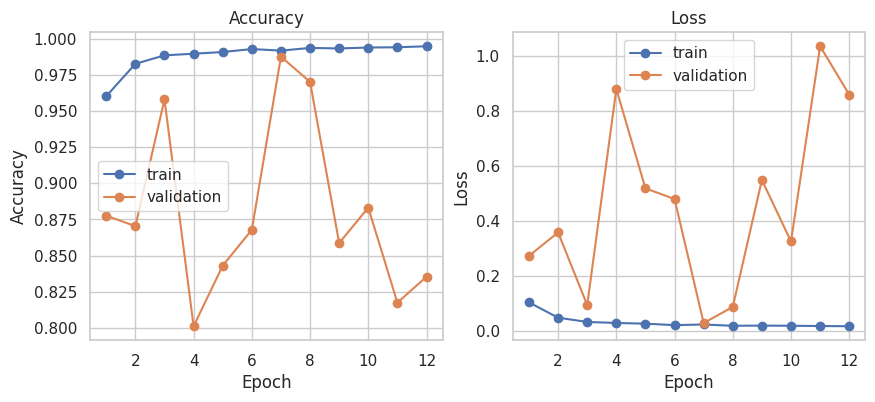

In [10]:
# 학습 history를 DataFrame으로 변환
df_history = pd.DataFrame(history.history)
display(df_history.tail())

# 시각화
plt.figure(figsize=(10,4))

# accuracy
plt.subplot(1,2,1)
plt.plot(df_history.index + 1, df_history['accuracy'], marker='o')
plt.plot(df_history.index + 1, df_history['val_accuracy'], marker='o')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train","validation"])

# loss
plt.subplot(1,2,2)
plt.plot(df_history.index + 1, df_history['loss'], marker='o')
plt.plot(df_history.index + 1, df_history['val_loss'], marker='o')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train","validation"])

plt.show()

In [11]:
# test eval
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy :", round(test_acc,4))

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9866 - loss: 0.0312
Test Accuracy : 0.9878


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
예측 확률 : [[0.]]
예측 클래스 : 0
실제 클래스 : 0


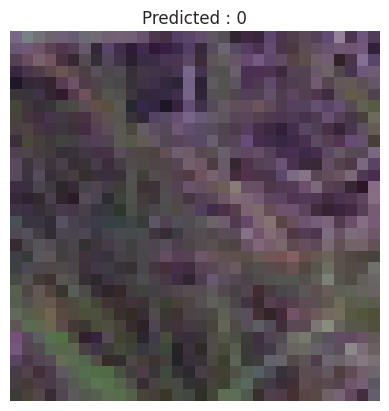

In [12]:
# use best model
best_model = keras.models.load_model('best_cactus_model.keras')

# test_generator에서 이미지 한 batch 가져오기
images, labels = next(test_generator)

# 첫 번째 이미지 선택 (batch 차원 유지)
sample = images[0:1]

# 예측
pred = best_model.predict(sample)

# 0.5 기준으로 클래스 결정
pred_class = (pred > 0.5).astype(int)

print("예측 확률 :", pred.round(4))
print("예측 클래스 :", pred_class[0][0])
print("실제 클래스 :", int(labels[0]))

# 시각화 (이미지는 3차원 형태 필요)
plt.imshow(sample[0])
plt.title(f"Predicted : {pred_class[0][0]}")
plt.axis('off')
plt.show()